#  Decision Tree — Overfitting & Underfitting
### Visualizing the Bias-Variance Tradeoff

---

##  Overview

This notebook visually demonstrates how **`max_depth`** controls the balance between **overfitting** and **underfitting** in a Decision Tree using the **Social Network Ads** dataset.

By plotting the **decision boundary** at different depths, we can see:
- **Underfitting** (too shallow) → simple boundaries that miss patterns
- **Just right** → boundaries that capture the real pattern
- **Overfitting** (too deep / `None`) → jagged boundaries that memorize noise

---

##  The Bias-Variance Tradeoff

| Problem | Cause | Symptom | Fix |
|---------|-------|---------|-----|
| **Underfitting** (High Bias) | Tree too shallow | Low train & test accuracy | Increase `max_depth` |
| **Overfitting** (High Variance) | Tree too deep | High train, low test accuracy | Decrease `max_depth` |
| **Good Fit** | Balanced depth | Good train & test accuracy | Tune with cross-validation |

```

      High Bias                      Good Fit              High Variance
     (Underfitting)                                       (Overfitting)
                
    max_depth:    1 ──────────────────── 3-5 ─────────────────── None
    Train acc:   Low ────────────────── Good ────────────────── ~100%
    Test acc:    Low ────────────────── Good ─────────────────── Low
```

### Import Required Libraries

In [10]:
import pandas as pd                              # Data loading and manipulation
import numpy as np                               # Numerical operations (meshgrid, linspace)
import matplotlib.pyplot as plt                  # Visualization
from sklearn.tree import DecisionTreeClassifier  # Decision Tree model

### Define the `analyze()` Function

This function:
1. Loads the Social Network Ads dataset
2. Trains a Decision Tree with a given `max_depth`
3. Creates a dense **meshgrid** over the feature space
4. Predicts the class for every point in the grid
5. Plots the resulting **decision boundary** as a filled contour

### How Decision Boundary Visualization Works:
- A meshgrid creates a fine grid of (Age, Salary) points covering the data space
- The trained model predicts a class label for every grid point
- `plt.contourf()` fills each region with a color based on the predicted class
- The actual data points are overlaid as a scatter plot
- The resulting plot shows exactly where the model draws its decision boundaries

In [53]:
def analyze(max_depth=None):
    """
    Train a Decision Tree and visualize its decision boundary.
    
    Parameters:
    -----------
    max_depth : int or None
        Maximum depth of the Decision Tree.
        - None  → Fully grown (likely overfitting)
        - 1-2   → Very shallow (likely underfitting)
        - 3-5   → Balanced (good generalization)
    
    """
    
    # Load the Social Network Ads dataset
    data = pd.read_csv('Social_Network_Ads.csv')

    # Use only 2 features: Age (col 2) and EstimatedSalary (col 3)
    # Using 2 features allows us to visualize the boundary in 2D
    X = data.iloc[:, 2:4].values   # Shape: (400, 2) — Age and Salary
    y = data.iloc[:, -1].values    # Last column: Purchased (0 or 1)

    # Train a Decision Tree with the given max_depth
    clf = DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(X, y)

    # Create a dense grid of points covering the entire feature space
    # 300 points per axis = 300x300 = 90,000 grid points total
    a = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)   # Age range
    b = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)   # Salary range
    
    # np.meshgrid creates a 2D grid from 1D arrays
    XX, YY = np.meshgrid(a, b)   # XX and YY are both (300, 300)

    # Flatten the grid into a list of (Age, Salary) pairs for prediction
    input_array = np.array([XX.ravel(), YY.ravel()]).T   # Shape: (90000, 2)

    # Predict class labels for all 90,000 grid points
    labels = clf.predict(input_array)   # Shape: (90000,)

    # Plot the decision boundary as a filled color map
    plt.contourf(XX, YY, labels.reshape(XX.shape), alpha=0.5)  # Background color = predicted class

    # Overlay the actual data points (colored by true class)
    plt.scatter(X[:, 0], X[:, 1], c=y)

    # Add informative labels
    plt.title(f'Decision Tree Boundary — max_depth={max_depth}')
    plt.xlabel('Age')
    plt.ylabel('Estimated Salary')

### Visualize Decision Boundaries at Different Depths

Run `analyze()` with different `max_depth` values to observe the spectrum from underfitting to overfitting.

**What to look for:**
- **`max_depth=1`** → A single straight split — severely underfitting, very simple boundary
- **`max_depth=2`** → Two splits — still too simple for this data
- **`max_depth=3`** → Starting to capture the actual pattern
- **`max_depth=5`** → Good balance — captures pattern without over-adapting to noise
- **`max_depth=None`** → Extremely jagged boundary — memorizes every data point (overfitting)

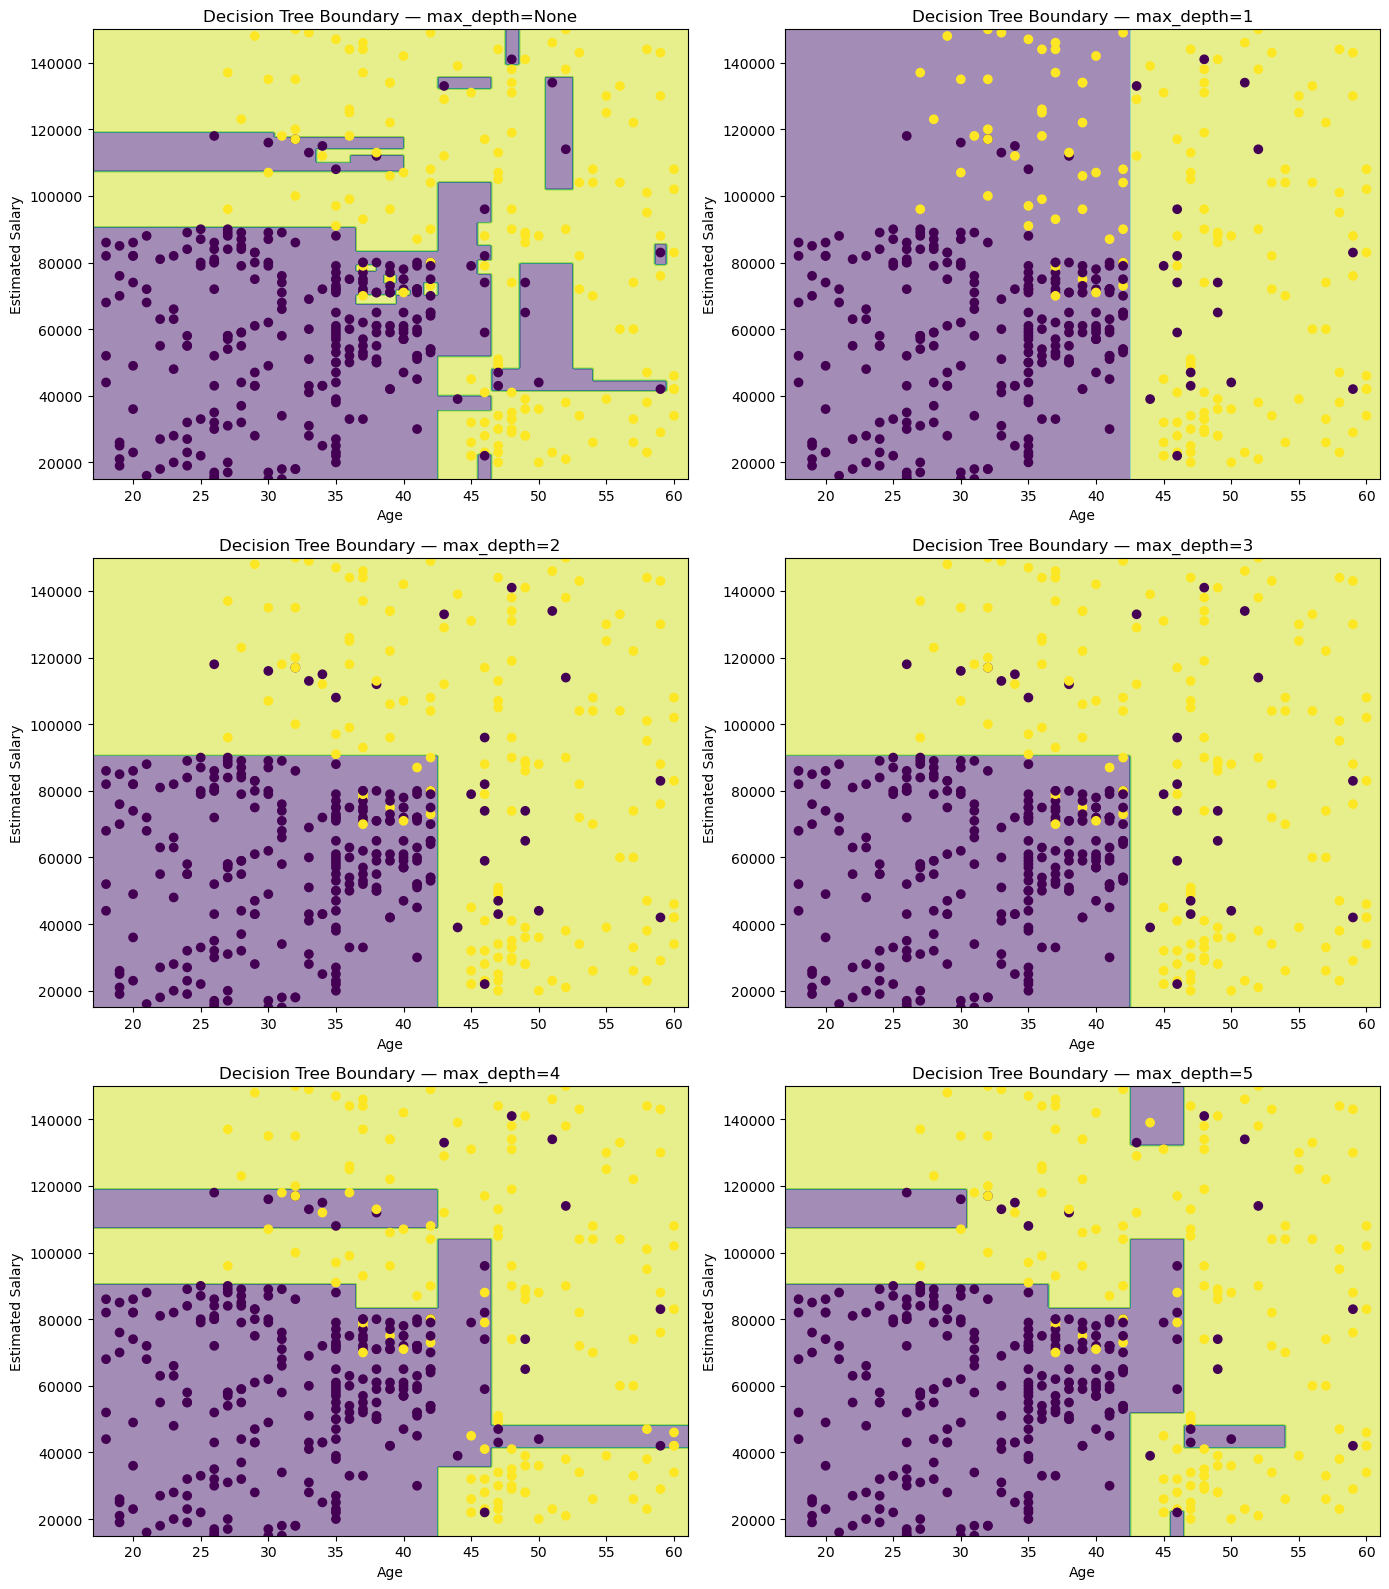

In [61]:
plt.figure(figsize=(14,16))
# Fully grown tree — max_depth=None means no restriction
# Expected: extremely jagged boundary that memorizes training data (OVERFITTING)
plt.subplot(3, 2, 1)
analyze(max_depth=None)

plt.subplot(3, 2, 2)
# Very shallow tree — only 1 level (1 split total)
# Expected: a single straight line boundary — UNDERFITTING
analyze(max_depth=1)

plt.subplot(3, 2, 3)
# 2-level tree
analyze(max_depth=2)

plt.subplot(3, 2, 4)
# 3-level tree
analyze(max_depth=3)

# 4-level tree
plt.subplot(3, 2, 5)
analyze(max_depth=4)

plt.subplot(3, 2, 6)
# 5-level tree — typically a good balance for this dataset
# Expected: reasonable boundary that captures the pattern without too much noise
analyze(max_depth=5)
plt.tight_layout()
plt.show()

### Validation Curve 

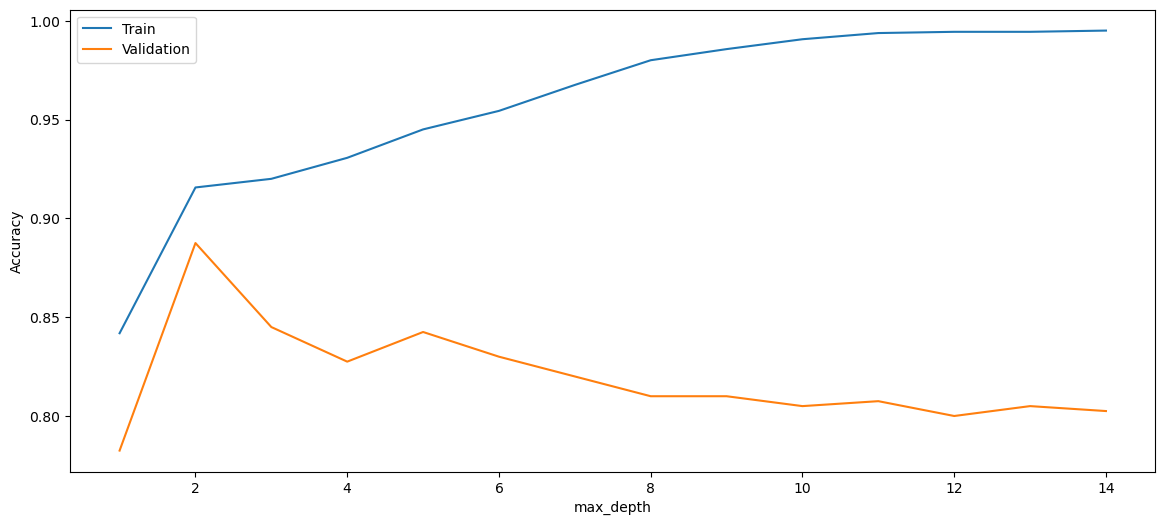

In [71]:
# Validation curve 

from sklearn.model_selection import validation_curve
data = pd.read_csv('Social_Network_Ads.csv')
X = data.iloc[:, 2:4].values   
y = data.iloc[:, -1].values
depths = range(1, 15)
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(), X, y,
    param_name='max_depth', param_range=depths, cv=5
)
plt.figure(figsize=(14,6))
plt.plot(depths, train_scores.mean(axis=1), label='Train')
plt.plot(depths, test_scores.mean(axis=1), label='Validation')
plt.legend()
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.show()

### Summary & Key Takeaways

###  Key Takeaways

1. **`max_depth=None`** → The tree grows until every leaf is pure. This **overfits** — the boundary wraps tightly around every training point, capturing noise.

2. **`max_depth=1`** → Only one split. The model is too simple to capture the actual pattern — **underfitting**.

3. **The sweet spot** (typically `max_depth=3–5` for this dataset) is where the boundary captures the real signal without following noise.
